# Import ibrary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# inisialisasi  file csv

In [2]:
data = pd.read_excel('Data_AF.xlsx', index_col=0)
data.head()

,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
Kabupaten/Kota Se Jawa Timur,,,,,,,,,,,,,,,,,,,,,
Kabupaten Pacitan,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,14.38,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
Kabupaten Ponorogo,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,16.87,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
Kabupaten Trenggalek,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,22.25,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
Kabupaten Tulungagung,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,15.17,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
Kabupaten Blitar,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,20.01,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


# Check Missing Value

In [3]:
data.isnull().sum()

Tingkat Pengangguran Terbuka                                        0
Tingkat Partisipasi Angkatan Kerja                                  0
Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan           0
Jumlah Pelanggan Air Bersih                                         0
Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan     0
Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal                   0
Jumlah Penduduk Bekerja 15 Tahun Keatas                             0
Jumlah Penduduk Sekolah 15 Tahun Keatas                             0
Distribusi Penduduk                                                 0
Persentase Perempuan Kawin di Bawah Umur                            0
Rasio Jenis Kelamin                                                 0
Angka Melek Huruf penduduk miskin 15-55tahun                        0
Ruta miskin yg menggunakan air layak                                0
Ruta miskin yg menggunakan jamban                                   0
Ruta miskin penerima

# Handling Missing Value

In [4]:
data.fillna(data.mean(numeric_only=True), inplace=True)
data.head()

,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
Kabupaten/Kota Se Jawa Timur,,,,,,,,,,,,,,,,,,,,,
Kabupaten Pacitan,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,14.38,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
Kabupaten Ponorogo,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,16.87,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
Kabupaten Trenggalek,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,22.25,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
Kabupaten Tulungagung,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,15.17,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
Kabupaten Blitar,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,20.01,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


# Memilih Variabel X dan Y 

In [11]:
y = data['Indeks Pembangunan Manusia ']
x = data[[
    'Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun ',
    'Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal ',
    'Tingkat Pengangguran Terbuka ',
    'Gini Rasio ',
    'Indeks Keparahan Kemiskinan (P2) ',
    'Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan ',
    'Angka Kesakitan ',
]]

# Hitung Matrik Korelasi

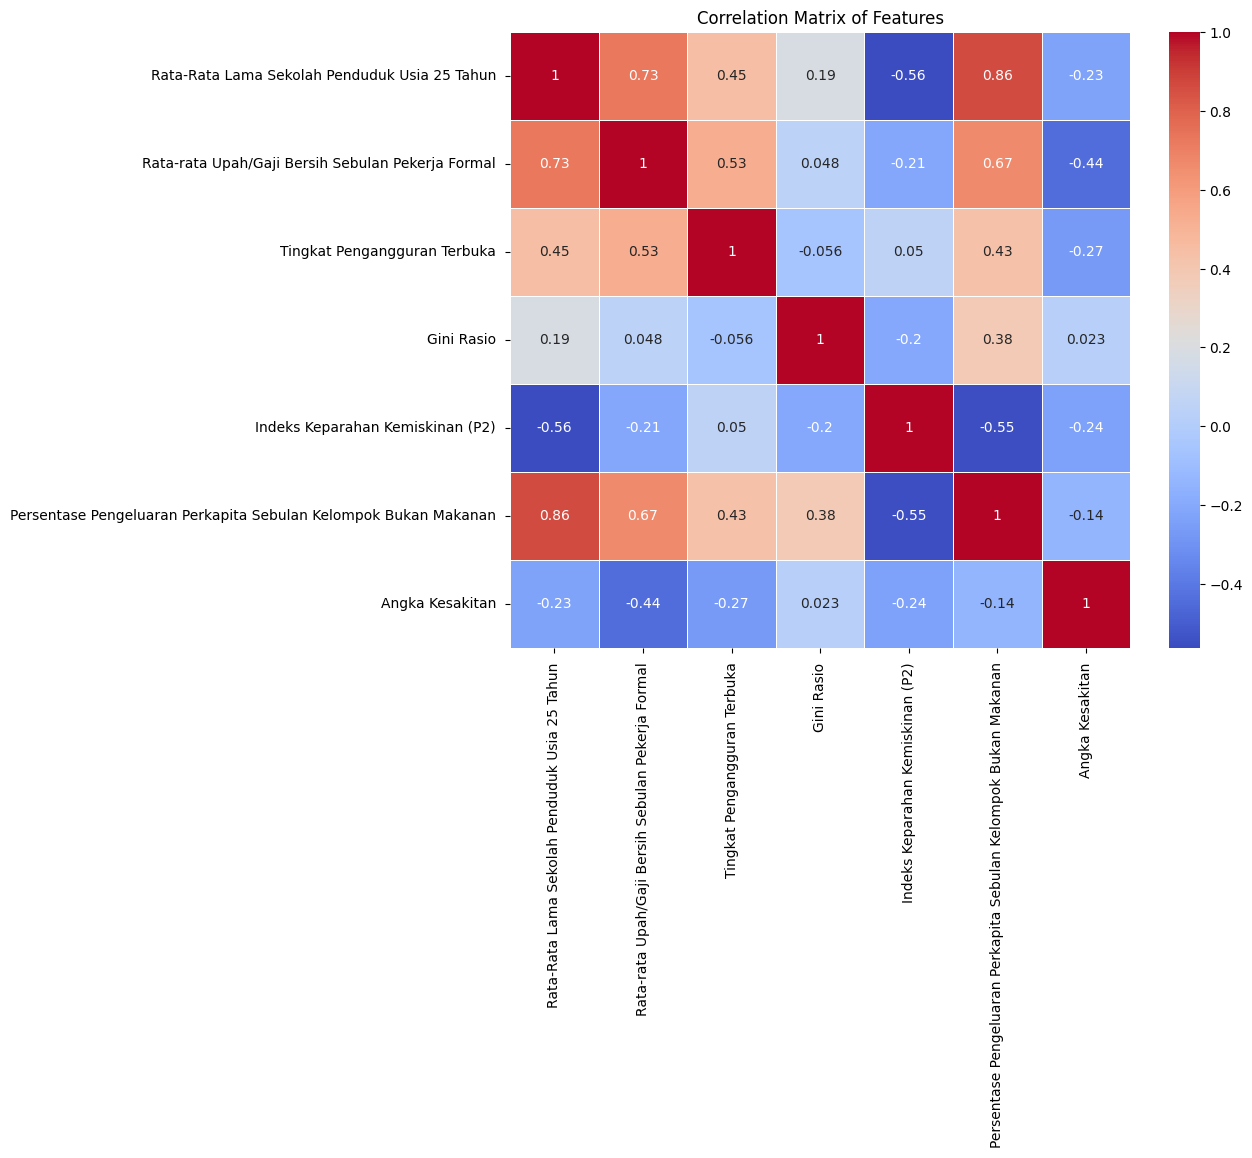

In [13]:
corr_matrix = x.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

# Uji Factor Analysis

In [16]:
from factor_analyzer.factor_analyzer import calculate_kmo,calculate_bartlett_sphericity

kmo_all, kmo_model = calculate_kmo(x)
chi_square_value, p_value = calculate_bartlett_sphericity(x)

print(f"KMO Test: {kmo_model}")
print(f"Bartlett's Test: Chi-Square={chi_square_value}, p-value={p_value}")

KMO Test: 0.7095997250909187
Bartlett's Test: Chi-Square=131.96928862535486, p-value=4.363903214162243e-18


# Menentukan Jumlah Fkator berdasarkan eigen  value

#  Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)